In [36]:
# ============================================================
# EPL Next-Week Predictor (NO-ODDS) — ENHANCED (AUTO CSV)
# - Auto-detects master vs base CSV (football-data)
# - Uses MORE rolling columns when available (shots, sot, corners, cards)
# - Prints dataset + rolling coverage summary
# - CatBoost prints learn+test loss during training
# - Calibrates with isotonic + saves artifacts
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, accuracy_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from catboost import CatBoostClassifier

# -------------------- CONFIG --------------------
CANDIDATES  = ["epl_master_train_full.csv", "epl_all_seasons_football_data.csv"]
MIN_DATE    = "2005-01-01"
NAN_THRESH  = 0.90
ROLL_N      = 12
RANDOM_SEED = 42

fixtures = [
    ("2026-02-28", "Wolves",       "Aston Villa"),
    ("2026-02-28", "Bournemouth",  "Sunderland"),
    ("2026-02-28", "Newcastle",    "Everton"),
    ("2026-02-28", "Burnley",      "Brentford"),
    ("2026-02-28", "Liverpool",    "West Ham"),
    ("2026-02-28", "Leeds",        "Man City"),
]
fixtures_df = pd.DataFrame(fixtures, columns=["date","home_team","away_team"])
fixtures_df["date"] = pd.to_datetime(fixtures_df["date"])

# -------------------- helpers --------------------
def pick_col(df, *names):
    for n in names:
        if n in df.columns:
            return n
    return None

def clean_team_name(x: str) -> str:
    if pd.isna(x):
        return x
    s = str(x).strip()
    repl = {
        "Wolverhampton": "Wolves",
        "Manchester City": "Man City",
        "Manchester United": "Man United",
        "West Ham United": "West Ham",
        "Nott'm Forest": "Nottm Forest",
        "Nottingham Forest": "Nottm Forest",
        "Spurs": "Tottenham",
    }
    return repl.get(s, s)

def parse_date_series(df):
    if "date" in df.columns:
        return pd.to_datetime(df["date"], errors="coerce")
    if "Date" in df.columns:
        tmp = df["Date"].astype(str).str.replace(r"[^0-9/]", "", regex=True)
        dt = pd.to_datetime(tmp, format="%d/%m/%y", errors="coerce")
        bad = dt.isna()
        if bad.any():
            dt.loc[bad] = pd.to_datetime(tmp.loc[bad], format="%d/%m/%Y", errors="coerce")
        return dt
    return pd.to_datetime(pd.Series([pd.NaT]*len(df)))

def to_num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

# -------------------- 0) Load best available CSV --------------------
CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    raise FileNotFoundError(f"Couldn't find any of: {CANDIDATES}")

df0 = pd.read_csv(CSV_PATH, low_memory=False)

# -------------------- 1) Standardize key columns --------------------
df0["date"] = parse_date_series(df0)
df0 = df0[df0["date"].notna()].copy()
df0 = df0.rename(columns={"_dt": "date"})

home_team_col = pick_col(df0, "home_team", "HomeTeam")
away_team_col = pick_col(df0, "away_team", "AwayTeam")
hg_col        = pick_col(df0, "home_goals", "FTHG")
ag_col        = pick_col(df0, "away_goals", "FTAG")
target_col    = pick_col(df0, "target", "FTR")  # accept either

if None in [home_team_col, away_team_col, hg_col, ag_col, target_col]:
    raise ValueError(
        "Missing required columns after auto-detect.\n"
        f"home_team_col={home_team_col}, away_team_col={away_team_col}, "
        f"hg_col={hg_col}, ag_col={ag_col}, target_col={target_col}\n"
        f"Found cols (sample): {list(df0.columns)[:40]}"
    )

df0 = df0.rename(columns={
    home_team_col: "home_team",
    away_team_col: "away_team",
    hg_col: "home_goals",
    ag_col: "away_goals",
    target_col: "target",
})

# Optional stats mapping (football-data style)
# We keep same names if already present in master.
optional_map = {
    "HS": "HS", "AS": "AS",
    "HST": "HST", "AST": "AST",
    "HC": "HC", "AC": "AC",
    "HY": "HY", "AY": "AY",
    "HR": "HR", "AR": "AR",
}
# (no rename needed, but this block is here for clarity/extension)

# Drop very-missing columns
df0 = df0.loc[:, df0.isna().mean() <= NAN_THRESH].copy()

# Clean basics
df0["home_team"] = df0["home_team"].map(clean_team_name)
df0["away_team"] = df0["away_team"].map(clean_team_name)

df0 = df0[df0["date"].notna() & (df0["date"] >= pd.to_datetime(MIN_DATE))].copy()
df0["target"] = df0["target"].astype(str).str.upper().str.strip()
df0 = df0[df0["target"].isin(["H", "D", "A"])].copy()

to_num(df0, ["home_goals", "away_goals", "HS","AS","HST","AST","HC","AC","HY","AY","HR","AR"])
df0 = df0[df0["home_goals"].notna() & df0["away_goals"].notna()].copy()

df0 = df0.sort_values("date").reset_index(drop=True)

print(f"Loaded: {CSV_PATH}")
print("Rows after cleanup:", len(df0))
print("Date range:", df0["date"].min().date(), "->", df0["date"].max().date())

# -------------------- 2) Build per-team rolling stats --------------------
def result_points(hg, ag):
    if hg > ag:  return 3, 0
    if hg < ag:  return 0, 3
    return 1, 1

# Which extra stats exist?
stat_defs = [
    ("shots",          "HS",  "AS"),
    ("shots_on_target","HST", "AST"),
    ("corners",        "HC",  "AC"),
    ("yellows",        "HY",  "AY"),
    ("reds",           "HR",  "AR"),
]
available_stats = [name for name, h, a in stat_defs if (h in df0.columns and a in df0.columns)]
print("Available stats for rolling form:", available_stats)

rows = []
for i, r in df0.iterrows():
    hg, ag = r["home_goals"], r["away_goals"]
    hp, ap = result_points(hg, ag)
    dt = r["date"]

    home_row = {"match_idx": i, "date": dt, "team": r["home_team"], "is_home": 1, "pts": hp, "gf": hg, "ga": ag}
    away_row = {"match_idx": i, "date": dt, "team": r["away_team"], "is_home": 0, "pts": ap, "gf": ag, "ga": hg}

    # add optional stats if present
    for name, hcol, acol in stat_defs:
        if hcol in df0.columns and acol in df0.columns:
            home_row[name] = r[hcol]
            away_row[name] = r[acol]

    rows.append(home_row)
    rows.append(away_row)

long = pd.DataFrame(rows).sort_values(["team","date","match_idx"]).reset_index(drop=True)

# Rolling means
base_roll_cols = ["pts","gf","ga"] + available_stats
for col in base_roll_cols:
    long[f"roll{ROLL_N}_{col}"] = (
        long.groupby("team")[col]
            .transform(lambda s: s.shift(1).rolling(ROLL_N, min_periods=ROLL_N).mean())
    )

# Build home/away feature frames
home_keep = [f"roll{ROLL_N}_pts", f"roll{ROLL_N}_gf", f"roll{ROLL_N}_ga"] + [f"roll{ROLL_N}_{c}" for c in available_stats]
away_keep = home_keep.copy()

home_feats = (
    long[long["is_home"] == 1]
    .set_index("match_idx")[home_keep]
    .rename(columns={c: "home_" + c.replace(f"roll{ROLL_N}_", f"roll{ROLL_N}_") + "_calc" for c in home_keep})
)

away_feats = (
    long[long["is_home"] == 0]
    .set_index("match_idx")[away_keep]
    .rename(columns={c: "away_" + c.replace(f"roll{ROLL_N}_", f"roll{ROLL_N}_") + "_calc" for c in away_keep})
)

df = df0.join(home_feats, how="left").join(away_feats, how="left")

# Diff features for all rolled cols
def make_diff(colname):
    return df[f"home_roll{ROLL_N}_{colname}_calc"] - df[f"away_roll{ROLL_N}_{colname}_calc"]

df[f"pts_diff_{ROLL_N}_calc"] = make_diff("pts")
df[f"gf_diff_{ROLL_N}_calc"]  = make_diff("gf")
df[f"ga_diff_{ROLL_N}_calc"]  = make_diff("ga")

for s in available_stats:
    df[f"{s}_diff_{ROLL_N}_calc"] = make_diff(s)

# Require enough history for base (pts/gf/ga). Optionally you can require all available_stats too.
feat_need = [
    f"home_roll{ROLL_N}_pts_calc", f"away_roll{ROLL_N}_pts_calc",
    f"home_roll{ROLL_N}_gf_calc",  f"away_roll{ROLL_N}_gf_calc",
    f"home_roll{ROLL_N}_ga_calc",  f"away_roll{ROLL_N}_ga_calc",
]
df_ok = df[df[feat_need].notna().all(axis=1)].copy()
print(f"Matches with enough history: {len(df_ok)} out of {len(df0)}")

df_ok = df_ok.sort_values("date").reset_index(drop=True)

# -------------------- 3) Train matrices --------------------
cat_feats = ["home_team", "away_team"]

num_feats = [
    f"home_roll{ROLL_N}_pts_calc", f"away_roll{ROLL_N}_pts_calc", f"pts_diff_{ROLL_N}_calc",
    f"home_roll{ROLL_N}_gf_calc",  f"away_roll{ROLL_N}_gf_calc",  f"gf_diff_{ROLL_N}_calc",
    f"home_roll{ROLL_N}_ga_calc",  f"away_roll{ROLL_N}_ga_calc",  f"ga_diff_{ROLL_N}_calc",
]

# Add optional rolling stats to features
for s in available_stats:
    num_feats += [
        f"home_roll{ROLL_N}_{s}_calc",
        f"away_roll{ROLL_N}_{s}_calc",
        f"{s}_diff_{ROLL_N}_calc",
    ]

feature_cols = cat_feats + num_feats

X = df_ok[feature_cols].copy()
y = df_ok["target"].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)

split_idx = int(len(df_ok) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_enc[:split_idx], y_enc[split_idx:]

cat_idx = [X_train.columns.get_loc(c) for c in cat_feats]

# -------------------- 4) Train CatBoost WITH eval_set (prints test loss) --------------------
model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    depth=6,
    learning_rate=0.08,
    iterations=1200,
    random_seed=RANDOM_SEED,
    verbose=200,
    use_best_model=True,
    od_type="Iter",
    od_wait=200
)

model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),
    verbose=200
)

# ---- RAW (uncalibrated) metrics to judge overfitting ----
P_tr_raw = model.predict_proba(X_train)
P_te_raw = model.predict_proba(X_test)

raw_train_ll = log_loss(y_train, P_tr_raw)
raw_test_ll  = log_loss(y_test,  P_te_raw)

raw_train_acc = accuracy_score(y_train, np.argmax(P_tr_raw, axis=1))
raw_test_acc  = accuracy_score(y_test,  np.argmax(P_te_raw, axis=1))

print(f"\n[RAW CatBoost] Train log loss: {raw_train_ll:.6f} | acc: {raw_train_acc:.4f}")
print(f"[RAW CatBoost] Test  log loss: {raw_test_ll:.6f} | acc: {raw_test_acc:.4f}")

print("Best iteration:", model.get_best_iteration())
best_val = model.get_best_score().get("validation", {}).get("MultiClass", None)
print("Best validation MultiClass:", best_val)

# -------------------- 5) Calibrate --------------------
cal = CalibratedClassifierCV(model, method="isotonic", cv="prefit")
cal.fit(X_test, y_test)

# -------------------- 6) Print calibrated train + test metrics --------------------
probs_train = cal.predict_proba(X_train)
probs_test  = cal.predict_proba(X_test)

train_ll = log_loss(y_train, probs_train)
test_ll  = log_loss(y_test, probs_test)

train_acc = accuracy_score(y_train, np.argmax(probs_train, axis=1))
test_acc  = accuracy_score(y_test,  np.argmax(probs_test,  axis=1))

print("\nRows used:", len(df_ok), "| Features:", len(feature_cols))
print("Target classes:", list(le.classes_))
print(f"Train log loss: {train_ll:.6f} | Train acc: {train_acc:.4f}")
print(f"Test  log loss: {test_ll:.6f} | Test  acc: {test_acc:.4f}")

# -------------------- 7) Fixture features from latest rolling values --------------------
latest = (
    long.dropna(subset=[f"roll{ROLL_N}_pts", f"roll{ROLL_N}_gf", f"roll{ROLL_N}_ga"])
        .sort_values(["team","date","match_idx"])
        .groupby("team", as_index=False)
        .tail(1)
        .set_index("team")
)

def get_latest_rolls(team: str, col: str):
    t = clean_team_name(team)
    if t not in latest.index:
        return np.nan
    return latest.loc[t, f"roll{ROLL_N}_{col}"]

fx = fixtures_df.copy()
fx["home_team"] = fx["home_team"].map(clean_team_name)
fx["away_team"] = fx["away_team"].map(clean_team_name)

# Fill base
for col in ["pts","gf","ga"] + available_stats:
    fx[f"home_roll{ROLL_N}_{col}_calc"] = fx["home_team"].apply(lambda t: get_latest_rolls(t, col))
    fx[f"away_roll{ROLL_N}_{col}_calc"] = fx["away_team"].apply(lambda t: get_latest_rolls(t, col))
    fx[f"{col}_diff_{ROLL_N}_calc"] = fx[f"home_roll{ROLL_N}_{col}_calc"] - fx[f"away_roll{ROLL_N}_{col}_calc"]

# Ensure all model features exist
missing_rows = fx[feature_cols].isna().any(axis=1)
if missing_rows.any():
    print("\n⚠️ Missing rolling history for these fixtures (team not present / not enough history):")
    display(fx.loc[missing_rows, ["date","home_team","away_team"]])

fx_ok = fx.loc[~missing_rows].copy()
P = cal.predict_proba(fx_ok[feature_cols])

class_names = list(le.classes_)
def idx(label): return class_names.index(label)

pA = P[:, idx("A")] if "A" in class_names else np.nan
pD = P[:, idx("D")] if "D" in class_names else np.nan
pH = P[:, idx("H")] if "H" in class_names else np.nan

summary = fx_ok[["date","home_team","away_team"]].copy()
summary["p_home"] = pH
summary["p_draw"] = pD
summary["p_away"] = pA
summary["pick"] = summary[["p_home","p_draw","p_away"]].idxmax(axis=1).str.replace("p_","", regex=False)
summary["confidence"] = summary[["p_home","p_draw","p_away"]].max(axis=1)

print("\n================= NEXT WEEK SUMMARY =================")
display(summary.sort_values("confidence", ascending=False).reset_index(drop=True))

# -------------------- 8) Save artifacts --------------------
import joblib

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(cal, os.path.join(SAVE_DIR, "epl_calibrated_model.pkl"))
joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))
joblib.dump(feature_cols, os.path.join(SAVE_DIR, "feature_columns.pkl"))

print("💾 Model, encoder, and feature list saved successfully.")
print("\n✅ Done.")

Loaded: epl_master_train_full.csv
Rows after cleanup: 7871
Date range: 2005-08-13 -> 2026-02-23
Available stats for rolling form: ['shots', 'shots_on_target', 'corners', 'yellows', 'reds']
Matches with enough history: 7463 out of 7871
0:	learn: 1.0815693	test: 1.0819707	best: 1.0819707 (0)	total: 18ms	remaining: 21.5s
200:	learn: 0.8572433	test: 1.0038321	best: 0.9930455 (67)	total: 1.85s	remaining: 9.18s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9930455446
bestIteration = 67

Shrink model to first 68 iterations.

[RAW CatBoost] Train log loss: 0.936006 | acc: 0.5504
[RAW CatBoost] Test  log loss: 0.993046 | acc: 0.5241
Best iteration: 67
Best validation MultiClass: 0.9930455445902701

Rows used: 7463 | Features: 26
Target classes: ['A', 'D', 'H']
Train log loss: 0.981425 | Train acc: 0.5557
Test  log loss: 0.970102 | Test  acc: 0.5295

================= NEXT WEEK SUMMARY =================


/cbica/home/dadashkj/.conda/envs/pushkar/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,date,home_team,away_team,p_home,p_draw,p_away,pick,confidence
0,2026-02-28,Liverpool,West Ham,0.637467,0.206418,0.156114,home,0.637467
1,2026-02-28,Leeds,Man City,0.226052,0.227798,0.546151,away,0.546151
2,2026-02-28,Wolves,Aston Villa,0.245478,0.272492,0.482030,away,0.482030
3,2026-02-28,Bournemouth,Sunderland,0.457814,0.263272,0.278914,home,0.457814
4,2026-02-28,Newcastle,Everton,0.433721,0.249417,0.316863,home,0.433721
5,2026-02-28,Burnley,Brentford,0.339778,0.280183,0.380039,away,0.380039


💾 Model, encoder, and feature list saved successfully.

✅ Done.


In [32]:
# ============================================================
# Interactive "Next Game" UI
# ✅ If ANY odds cell is empty -> fill missing odds from HISTORICAL odds in df0
# ✅ Accepts American (+330/-120) OR Decimal (4.30/1.83) in the boxes
# ✅ If no exact fixture history, falls back to team-level (home team at home, away team away)
# ✅ If still none, falls back to league median odds (last resort)
# ============================================================

import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- requires these to exist from training cell ----
# df0, cal, le, feature_cols, ROLL_N, clean_team_name, get_latest_rolls

# -------------------- pick which odds columns exist in df0 --------------------
# We'll try common names. Use the first triplet we find.
ODDS_CANDIDATES = [
    ("odds_home","odds_draw","odds_away"),
    ("B365H","B365D","B365A"),
    ("PSH","PSD","PSA"),
    ("WHH","WHD","WHA"),
    ("VCH","VCD","VCA"),
]

def _find_odds_cols(df):
    for h,d,a in ODDS_CANDIDATES:
        if {h,d,a}.issubset(df.columns):
            return (h,d,a)
    return None

odds_cols = _find_odds_cols(df0)
if odds_cols is None:
    print("⚠️ No odds columns found in df0. Historical-odds fallback will NOT work.")
    print("   Add odds columns (e.g., odds_home/odds_draw/odds_away or B365H/B365D/B365A) to df0, or enter odds manually.")
else:
    print(f"✅ Using historical odds columns: {odds_cols}")

# -------------------- helpers --------------------
class_names = list(le.classes_)
def idx(label): return class_names.index(label)

def _is_finite(x):
    return x is not None and np.isfinite(x)

def _parse_user_odds_to_decimal(s: str):
    """
    Accepts:
      - "" -> None
      - "+330" / "-120" (American) -> decimal
      - "4.30" / "1.83" (Decimal) -> decimal
      - "330" (assume American) -> decimal
    """
    s = (s or "").strip()
    if s == "":
        return None

    # normalize
    s2 = s.replace(" ", "")
    try:
        # If user typed "+330" or "-120"
        if s2.startswith("+") or s2.startswith("-"):
            a = float(s2)
            # American to decimal
            if a > 0:
                return 1.0 + (a / 100.0)
            else:
                return 1.0 + (100.0 / abs(a))

        # else numeric
        x = float(s2)

        # Heuristic:
        # - Decimal odds are typically > 1.01 and often < 20
        # - American odds are often >= 100 in magnitude
        if x >= 1.01 and x <= 25.0:
            # treat as decimal
            return x
        else:
            # treat as American (e.g., 330, 120, -120)
            a = x
            if a > 0:
                return 1.0 + (a / 100.0)
            else:
                return 1.0 + (100.0 / abs(a))
    except Exception:
        return None

def implied_probs_from_decimal_odds(dec_h, dec_d, dec_a):
    """
    Convert decimal odds -> (p_fair_home, p_fair_draw, p_fair_away, overround).
    """
    if not (_is_finite(dec_h) and _is_finite(dec_d) and _is_finite(dec_a)):
        return None, None, None, None

    p_raw = np.array([1/dec_h, 1/dec_d, 1/dec_a], dtype=float)
    overround = float(p_raw.sum() - 1.0)
    p_fair = p_raw / p_raw.sum()
    return float(p_fair[0]), float(p_fair[1]), float(p_fair[2]), float(overround)

def get_historical_odds_decimal(home_team, away_team, n_last=8):
    """
    Returns (dec_h, dec_d, dec_a, source_str) using df0.
    Priority:
      1) Exact fixture history: same home_team & away_team (last n_last)
      2) Team-level: home team at home (any opponent) + away team away (any opponent) (last n_last each)
         - combine by median
      3) League fallback: median odds across all matches (last resort)
    """
    if odds_cols is None:
        return None, None, None, "no_odds_columns"

    hcol, dcol, acol = odds_cols
    ht = clean_team_name(home_team)
    at = clean_team_name(away_team)

    dfx = df0.copy()
    # ensure cleaned teams (in case df0 isn’t already cleaned)
    dfx["home_team"] = dfx["home_team"].map(clean_team_name)
    dfx["away_team"] = dfx["away_team"].map(clean_team_name)
    dfx = dfx.sort_values("date")

    def _med_triplet(sub):
        sub = sub[[hcol, dcol, acol]].apply(pd.to_numeric, errors="coerce")
        sub = sub.dropna()
        if len(sub) == 0:
            return None
        m = sub.median()
        return float(m[hcol]), float(m[dcol]), float(m[acol])

    # 1) exact fixture
    exact = dfx[(dfx["home_team"] == ht) & (dfx["away_team"] == at)].tail(n_last)
    t = _med_triplet(exact)
    if t is not None:
        return (*t, f"exact_fixture_median_last{min(n_last, len(exact))}")

    # 2) team-level: home team at home + away team away
    home_hist = dfx[dfx["home_team"] == ht].tail(n_last)
    away_hist = dfx[dfx["away_team"] == at].tail(n_last)

    t1 = _med_triplet(home_hist)
    t2 = _med_triplet(away_hist)

    if t1 is not None or t2 is not None:
        vals = []
        if t1 is not None: vals.append(t1)
        if t2 is not None: vals.append(t2)
        dec_h = float(np.median([v[0] for v in vals]))
        dec_d = float(np.median([v[1] for v in vals]))
        dec_a = float(np.median([v[2] for v in vals]))
        return dec_h, dec_d, dec_a, "team_level_median"

    # 3) league fallback
    league = dfx.tail(4000)  # keep it reasonably recent-ish; tweak if you want
    t3 = _med_triplet(league)
    if t3 is not None:
        return (*t3, "league_median")

    return None, None, None, "no_history_found"

def build_fixture_row(date_val, home_team, away_team):
    fx = pd.DataFrame([{
        "date": pd.to_datetime(date_val),
        "home_team": clean_team_name(home_team),
        "away_team": clean_team_name(away_team),
    }])

    fx[[f"home_roll{ROLL_N}_pts_calc", f"home_roll{ROLL_N}_gf_calc", f"home_roll{ROLL_N}_ga_calc"]] = fx["home_team"].apply(
        lambda t: pd.Series(get_latest_rolls(t))
    )
    fx[[f"away_roll{ROLL_N}_pts_calc", f"away_roll{ROLL_N}_gf_calc", f"away_roll{ROLL_N}_ga_calc"]] = fx["away_team"].apply(
        lambda t: pd.Series(get_latest_rolls(t))
    )

    fx[f"pts_diff_{ROLL_N}_calc"] = fx[f"home_roll{ROLL_N}_pts_calc"] - fx[f"away_roll{ROLL_N}_pts_calc"]
    fx[f"gf_diff_{ROLL_N}_calc"]  = fx[f"home_roll{ROLL_N}_gf_calc"]  - fx[f"away_roll{ROLL_N}_gf_calc"]
    fx[f"ga_diff_{ROLL_N}_calc"]  = fx[f"home_roll{ROLL_N}_ga_calc"]  - fx[f"away_roll{ROLL_N}_ga_calc"]
    return fx

def predict_one(fx_row):
    P = cal.predict_proba(fx_row[feature_cols])
    pH = P[0, idx("H")] if "H" in class_names else np.nan
    pD = P[0, idx("D")] if "D" in class_names else np.nan
    pA = P[0, idx("A")] if "A" in class_names else np.nan
    return float(pH), float(pD), float(pA)

# -------------------- UI widgets --------------------
teams = sorted(pd.unique(pd.concat([df0["home_team"], df0["away_team"]], ignore_index=True)).tolist())

date_picker = widgets.DatePicker(description="Date:", value=pd.Timestamp("2026-02-28").date())

home_dd = widgets.Dropdown(options=teams, description="Home:", value="Wolves" if "Wolves" in teams else teams[0],
                           layout=widgets.Layout(width="320px"))
away_dd = widgets.Dropdown(options=teams, description="Away:", value="Aston Villa" if "Aston Villa" in teams else teams[1],
                           layout=widgets.Layout(width="320px"))

# odds inputs (leave blank to trigger historical fill)
odds_home = widgets.Text(description="Odds H:", value="", placeholder="e.g. +330 or 4.30", layout=widgets.Layout(width="260px"))
odds_draw = widgets.Text(description="Odds D:", value="", placeholder="e.g. +260 or 3.60", layout=widgets.Layout(width="260px"))
odds_away = widgets.Text(description="Odds A:", value="", placeholder="e.g. -120 or 1.83", layout=widgets.Layout(width="260px"))

edge_thresh = widgets.FloatSlider(
    description="Edge ≥", min=0.0, max=0.15, step=0.005, value=0.03,
    readout_format=".3f", layout=widgets.Layout(width="420px")
)

btn = widgets.Button(description="Predict", button_style="primary", icon="check")
out = widgets.Output()

# -------------------- click logic --------------------
def on_click(_):
    with out:
        clear_output(wait=True)

        dt = date_picker.value
        ht = home_dd.value
        at = away_dd.value

        if ht == at:
            print("⚠️ Home and Away can’t be the same team.")
            return

        # ---- model features ----
        fx = build_fixture_row(dt, ht, at)
        if fx[feature_cols].isna().any(axis=1).iloc[0]:
            print("⚠️ Missing rolling history for one of these teams (not in data / not enough history).")
            display(fx[["date","home_team","away_team"]])
            return

        pH, pD, pA = predict_one(fx)
        probs = pd.Series({"H": pH, "D": pD, "A": pA})
        pick = probs.idxmax()
        conf = probs.max()

        # ---- odds: user -> decimal; fill missing from history ----
        user_dec_h = _parse_user_odds_to_decimal(odds_home.value)
        user_dec_d = _parse_user_odds_to_decimal(odds_draw.value)
        user_dec_a = _parse_user_odds_to_decimal(odds_away.value)

        need_fill = (user_dec_h is None) or (user_dec_d is None) or (user_dec_a is None)

        hist_dec_h = hist_dec_d = hist_dec_a = None
        hist_src = None
        if need_fill:
            hist_dec_h, hist_dec_d, hist_dec_a, hist_src = get_historical_odds_decimal(ht, at)

        dec_h = user_dec_h if user_dec_h is not None else hist_dec_h
        dec_d = user_dec_d if user_dec_d is not None else hist_dec_d
        dec_a = user_dec_a if user_dec_a is not None else hist_dec_a

        # If still missing, we can only show model probs
        have_all_odds = _is_finite(dec_h) and _is_finite(dec_d) and _is_finite(dec_a)

        # ---- header ----
        print(f"{pd.to_datetime(dt).date()} | {clean_team_name(ht)} vs {clean_team_name(at)}")
        print(f"Model pick: {pick}  (confidence={conf:.3f})")

        if have_all_odds:
            pbh, pbd, pba, overround = implied_probs_from_decimal_odds(dec_h, dec_d, dec_a)
            if hist_src is not None and need_fill:
                print(f"Odds filled from history: {hist_src}")
            print(f"Odds used (decimal): H={dec_h:.3f}  D={dec_d:.3f}  A={dec_a:.3f}")
            print(f"Overround (book margin): {overround:.3f}")

            rows = []
            for lab, name, dec in [("H","Home (H)",dec_h), ("D","Draw (D)",dec_d), ("A","Away (A)",dec_a)]:
                p_model = float(probs[lab])
                p_book  = {"H": pbh, "D": pbd, "A": pba}[lab]
                edge    = p_model - p_book
                ev      = (p_model * dec) - 1.0
                rows.append([name, p_model, p_book, edge, ev])

            table = pd.DataFrame(rows, columns=["Outcome","p_model","p_book","edge","EV"])

            best = table.loc[table["EV"].idxmax()]
            do_bet = (best["EV"] > 0) and (best["edge"] >= float(edge_thresh.value))

            print(f"Best EV side: {best['Outcome']} | EV={best['EV']:.3f} | edge={best['edge']:.3f}")
            print("Suggestion:", "BET ✅" if do_bet else "NO BET ❌")

            display(table.style.format({"p_model":"{:.3f}","p_book":"{:.3f}","edge":"{:.3f}","EV":"{:.3f}"}))
        else:
            print("Odds not provided (or could not be filled from history) → showing model probabilities only.")
            table = pd.DataFrame(
                [["Home (H)", float(probs["H"])],
                 ["Draw (D)", float(probs["D"])],
                 ["Away (A)", float(probs["A"])]],
                columns=["Outcome","p_model"]
            )
            display(table.style.format({"p_model":"{:.3f}"}))

btn.on_click(on_click)

ui1 = widgets.HBox([date_picker, home_dd, away_dd])
ui2 = widgets.HBox([odds_home, odds_draw, odds_away])
ui3 = widgets.HBox([edge_thresh, btn])

display(ui1, ui2, ui3, out)
print("✅ Leave any odds box blank to auto-fill from historical odds (if df0 has odds columns). Then click Predict.")

✅ Using historical odds columns: ('odds_home', 'odds_draw', 'odds_away')


Output()

✅ Leave any odds box blank to auto-fill from historical odds (if df0 has odds columns). Then click Predict.


✅ odds columns: ('odds_home', 'odds_draw', 'odds_away')
{'start_date': '2025-08-01', 'end_date': '2026-02-28', 'roll_n': 5, 'edge_thresh': 0.0, 'n_matches_scored': 271, 'n_bets': 244, 'total_staked': 244.0, 'net_profit': -24.240000000000002, 'ROI': -0.09934426229508198, 'odds_cols_used': ('odds_home', 'odds_draw', 'odds_away'), 'model_features_used': 26, 'extra_stats_used': ['shots', 'shots_on_target', 'corners', 'yellows', 'reds']}


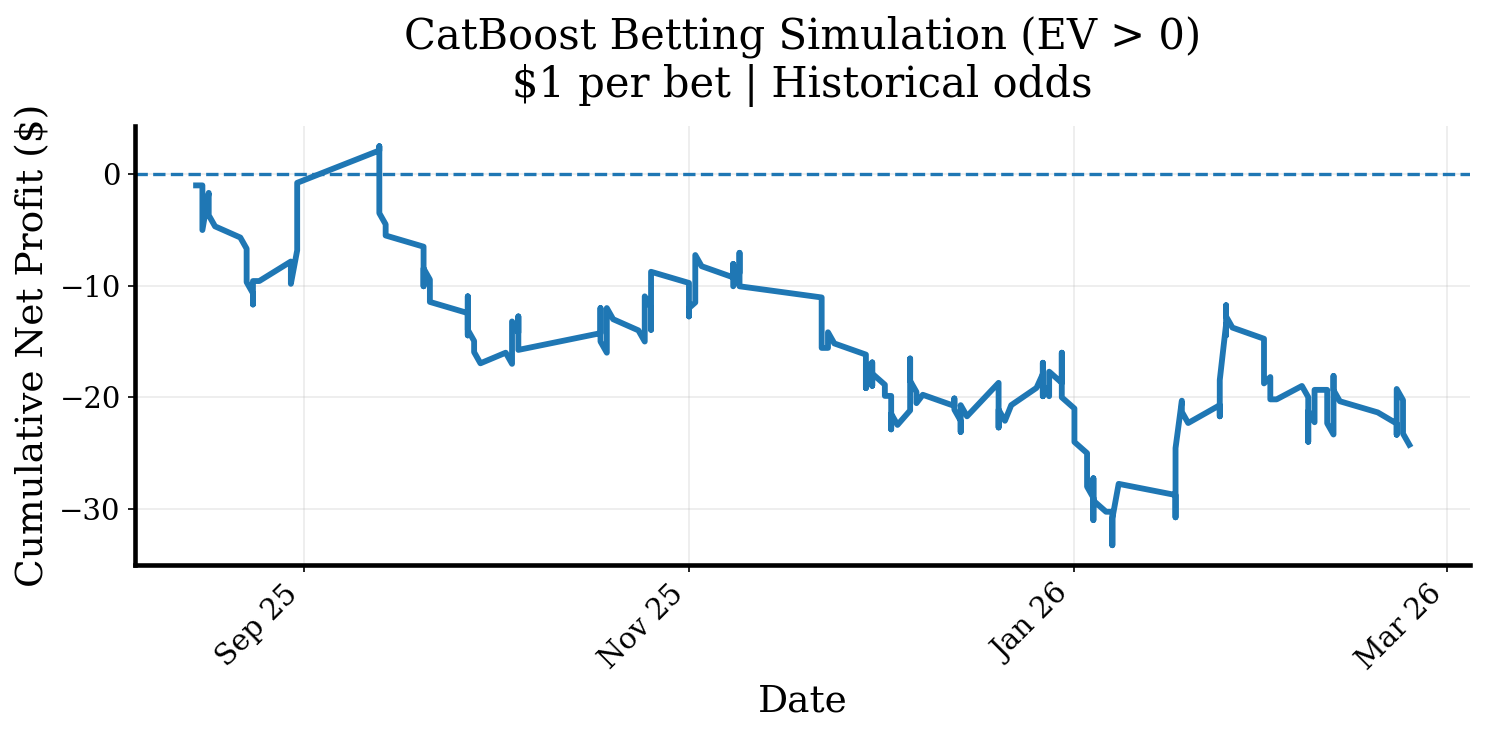

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# CatBoost EV Backtest using HISTORY odds only
# - Rebuilds features from df0 to guarantee alignment
# - Bets only if (best_EV > 0) and (best_edge >= edge_thresh)
# - $1 stake per bet
# - Nature-ish plot with month-year ticks (e.g., "Mar 25") at 45°
#
# Requires already trained:
#   cal (CalibratedClassifierCV), le (LabelEncoder)
# And your clean_team_name function (optional but recommended)
# ============================================================

ROLL_N = 5
NAN_THRESH = 0.90
STAKE = 1.0
EDGE_THRESH = 0.00  # set 0.03 for stricter
START_DATE = "2025-08-01"
END_DATE = None  # None = today()

ODDS_CANDIDATES = [
    ("odds_home","odds_draw","odds_away"),
    ("B365H","B365D","B365A"),
    ("PSH","PSD","PSA"),
    ("WHH","WHD","WHA"),
    ("VCH","VCD","VCA"),
]

def find_odds_triplet(df):
    for h,d,a in ODDS_CANDIDATES:
        if {h,d,a}.issubset(df.columns):
            return (h,d,a)
    return None

def implied_probs_from_decimal_odds(dec_h, dec_d, dec_a):
    if not (np.isfinite(dec_h) and np.isfinite(dec_d) and np.isfinite(dec_a)):
        return None
    p_raw = np.array([1/dec_h, 1/dec_d, 1/dec_a], dtype=float)
    overround = float(p_raw.sum() - 1.0)
    p_fair = p_raw / p_raw.sum()
    return float(p_fair[0]), float(p_fair[1]), float(p_fair[2]), overround

def result_points(hg, ag):
    if hg > ag:  return 3, 0
    if hg < ag:  return 0, 3
    return 1, 1

def backtest_catboost_ev_from_df0(
    df0,
    cal, le,
    start_date=START_DATE,
    end_date=END_DATE,
    roll_n=ROLL_N,
    stake=STAKE,
    edge_thresh=EDGE_THRESH,
):
    df0 = df0.copy()

    # --- must have date + teams + goals + target ---
    if "date" not in df0.columns:
        raise ValueError("df0 must contain a 'date' column.")
    df0["date"] = pd.to_datetime(df0["date"], errors="coerce")

    # optional cleaning
    if "clean_team_name" in globals():
        df0["home_team"] = df0["home_team"].map(clean_team_name)
        df0["away_team"] = df0["away_team"].map(clean_team_name)

    # --- odds columns ---
    odds_cols = find_odds_triplet(df0)
    if odds_cols is None:
        raise ValueError(f"No odds columns found. Tried: {ODDS_CANDIDATES}")
    hcol, dcol, acol = odds_cols
    print("✅ odds columns:", odds_cols)

    # required core cols
    need_core = ["date","home_team","away_team","home_goals","away_goals","target"]
    missing = [c for c in need_core if c not in df0.columns]
    if missing:
        raise ValueError(f"df0 missing required columns: {missing}")

    df0["home_goals"] = pd.to_numeric(df0["home_goals"], errors="coerce")
    df0["away_goals"] = pd.to_numeric(df0["away_goals"], errors="coerce")
    df0["target"] = df0["target"].astype(str).str.strip().str.upper()
    df0 = df0.dropna(subset=["date","home_team","away_team","home_goals","away_goals","target"]).copy()
    df0 = df0[df0["target"].isin(["H","D","A"])].copy()

    # odds to numeric
    df0[[hcol,dcol,acol]] = df0[[hcol,dcol,acol]].apply(pd.to_numeric, errors="coerce")

    # sort chronologically
    df0 = df0.sort_values("date").reset_index(drop=True)
    df0["match_idx"] = np.arange(len(df0))

    # ------------------------------------------------------------
    # Determine EXACT feature columns expected by the trained model
    # ------------------------------------------------------------
    # CalibratedClassifierCV stores an internal calibrated classifier
    # We can safely grab expected feature names from the underlying CatBoost model.
    base_est = getattr(cal, "base_estimator_", None)
    if base_est is None:
        # older sklearn may store estimator differently
        base_est = getattr(cal, "estimator", None)

    model_feature_cols = None
    if base_est is not None and hasattr(base_est, "feature_names_"):
        model_feature_cols = list(base_est.feature_names_)
    elif hasattr(cal, "feature_names_in_"):
        model_feature_cols = list(cal.feature_names_in_)
    else:
        # last resort: assume old "base" set
        model_feature_cols = [
            "home_team","away_team",
            f"home_roll{roll_n}_pts_calc", f"away_roll{roll_n}_pts_calc", f"pts_diff_{roll_n}_calc",
            f"home_roll{roll_n}_gf_calc",  f"away_roll{roll_n}_gf_calc",  f"gf_diff_{roll_n}_calc",
            f"home_roll{roll_n}_ga_calc",  f"away_roll{roll_n}_ga_calc",  f"ga_diff_{roll_n}_calc",
        ]

    # We will build rolling stats for base + optional extras IF present in df0
    # (and only needed if the model asks for them)
    stat_defs = [
        ("shots",           "HS",  "AS"),
        ("shots_on_target", "HST", "AST"),
        ("corners",         "HC",  "AC"),
        ("yellows",         "HY",  "AY"),
        ("reds",            "HR",  "AR"),
    ]

    # Decide which stat names are needed by the model
    needed_stats = []
    for stat_name, hstat, astat in stat_defs:
        # model columns look like home_roll5_shots_calc etc.
        need_any = any(f"_{stat_name}_" in c or c.endswith(f"_{stat_name}_calc") for c in model_feature_cols)
        if need_any and (hstat in df0.columns and astat in df0.columns):
            needed_stats.append(stat_name)

    # also ensure numeric conversion for any needed stats
    for stat_name, hstat, astat in stat_defs:
        if stat_name in needed_stats:
            df0[hstat] = pd.to_numeric(df0[hstat], errors="coerce")
            df0[astat] = pd.to_numeric(df0[astat], errors="coerce")

    # ---------- build rolling features (base + needed extras) ----------
    rows = []
    for i, r in df0.iterrows():
        hg, ag = float(r["home_goals"]), float(r["away_goals"])
        hp, ap = result_points(hg, ag)
        dt = r["date"]

        home_row = {"match_idx": i, "date": dt, "team": r["home_team"], "is_home": 1, "pts": hp, "gf": hg, "ga": ag}
        away_row = {"match_idx": i, "date": dt, "team": r["away_team"], "is_home": 0, "pts": ap, "gf": ag, "ga": hg}

        # add needed extras if present
        for stat_name, hstat, astat in stat_defs:
            if stat_name in needed_stats:
                home_row[stat_name] = r[hstat]
                away_row[stat_name] = r[astat]

        rows.append(home_row)
        rows.append(away_row)

    long = pd.DataFrame(rows).sort_values(["team","date","match_idx"]).reset_index(drop=True)

    roll_cols = ["pts","gf","ga"] + needed_stats
    for col in roll_cols:
        long[f"roll{roll_n}_{col}"] = (
            long.groupby("team")[col]
                .transform(lambda s: s.shift(1).rolling(roll_n, min_periods=roll_n).mean())
        )

    # home/away roll feature frames
    home_roll_cols = [f"roll{roll_n}_{c}" for c in roll_cols]
    away_roll_cols = home_roll_cols.copy()

    home_feats = (
        long[long["is_home"] == 1]
        .set_index("match_idx")[home_roll_cols]
        .rename(columns={c: f"home_{c}_calc" for c in home_roll_cols})
    )
    away_feats = (
        long[long["is_home"] == 0]
        .set_index("match_idx")[away_roll_cols]
        .rename(columns={c: f"away_{c}_calc" for c in away_roll_cols})
    )

    sim = df0.join(home_feats, on="match_idx", how="left").join(away_feats, on="match_idx", how="left")

    # diffs for all roll cols
    for c in roll_cols:
        sim[f"{c}_diff_{roll_n}_calc"] = sim[f"home_roll{roll_n}_{c}_calc"] - sim[f"away_roll{roll_n}_{c}_calc"]

    # ---------- filter to date window ----------
    if end_date is None:
        end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

    # keep only rows with odds + required model features
    sim = sim.dropna(subset=["date", hcol, dcol, acol]).copy()
    sim = sim[(sim["date"] >= pd.to_datetime(start_date)) & (sim["date"] <= pd.to_datetime(end_date))].copy()
    sim = sim.sort_values("date").reset_index(drop=True)

    # Ensure ALL model features exist (or bail with a clear message)
    missing_feats = [c for c in model_feature_cols if c not in sim.columns]
    if missing_feats:
        raise ValueError(
            "Backtest cannot run because these model features are missing in sim:\n"
            f"{missing_feats}\n"
            "This usually means your df0 does not contain the raw columns needed to build them (e.g., HS/AS etc.) "
            "or you trained on a different feature set."
        )

    # Also drop rows with NaNs in any model features
    sim = sim.dropna(subset=model_feature_cols).copy()
    if len(sim) == 0:
        raise ValueError("No matches left after filtering. (date window / missing odds / insufficient roll history)")

    # ---------- model probs ----------
    P = cal.predict_proba(sim[model_feature_cols])

    class_names = list(le.classes_)
    lab_to_i = {lab:i for i,lab in enumerate(class_names)}
    for lab in ["H","D","A"]:
        if lab not in lab_to_i:
            raise ValueError(f"LabelEncoder must include H/D/A. Got {class_names}")

    sim["pH"] = P[:, lab_to_i["H"]]
    sim["pD"] = P[:, lab_to_i["D"]]
    sim["pA"] = P[:, lab_to_i["A"]]

    # ---------- book fair probs + EV/edge ----------
    fair = sim.apply(lambda r: implied_probs_from_decimal_odds(r[hcol], r[dcol], r[acol]), axis=1)
    fair = pd.DataFrame(fair.tolist(), columns=["pbh","pbd","pba","overround"], index=sim.index)
    sim = pd.concat([sim, fair], axis=1)

    sim["EV_H"] = sim["pH"] * sim[hcol] - 1.0
    sim["EV_D"] = sim["pD"] * sim[dcol] - 1.0
    sim["EV_A"] = sim["pA"] * sim[acol] - 1.0

    sim["edge_H"] = sim["pH"] - sim["pbh"]
    sim["edge_D"] = sim["pD"] - sim["pbd"]
    sim["edge_A"] = sim["pA"] - sim["pba"]

    def choose_bet(r):
        evs = {"H": r["EV_H"], "D": r["EV_D"], "A": r["EV_A"]}
        edges = {"H": r["edge_H"], "D": r["edge_D"], "A": r["edge_A"]}
        side = max(evs, key=lambda k: evs[k])
        do = (evs[side] > 0) and (edges[side] >= float(edge_thresh))
        dec = r[hcol] if side=="H" else (r[dcol] if side=="D" else r[acol])
        return pd.Series([side, do, evs[side], edges[side], dec])

    sim[["bet_side","do_bet","best_EV","best_edge","dec_odds"]] = sim.apply(choose_bet, axis=1)
    sim["do_bet"] = sim["do_bet"].astype(bool)

    sim["bet_profit"] = 0.0
    win = sim["do_bet"] & (sim["target"] == sim["bet_side"])
    lose = sim["do_bet"] & (~win)

    sim.loc[win, "bet_profit"] = (sim.loc[win, "dec_odds"] - 1.0) * float(stake)
    sim.loc[lose, "bet_profit"] = -float(stake)
    sim["cum_profit"] = sim["bet_profit"].cumsum()

    n_bets = int(sim["do_bet"].sum())
    total_staked = float(n_bets * stake)
    net_profit = float(sim["cum_profit"].iloc[-1])
    roi = net_profit / total_staked if total_staked > 0 else 0.0

    summary = {
        "start_date": str(pd.to_datetime(start_date).date()),
        "end_date": str(pd.to_datetime(end_date).date()),
        "roll_n": int(roll_n),
        "edge_thresh": float(edge_thresh),
        "n_matches_scored": int(len(sim)),
        "n_bets": n_bets,
        "total_staked": total_staked,
        "net_profit": net_profit,
        "ROI": roi,
        "odds_cols_used": (hcol,dcol,acol),
        "model_features_used": len(model_feature_cols),
        "extra_stats_used": needed_stats,
    }
    return summary, sim

# -------------------- RUN --------------------
summary_cat, sim_cat = backtest_catboost_ev_from_df0(
    df0=df0,
    cal=cal,
    le=le,
    start_date=START_DATE,
    end_date=END_DATE,
    roll_n=ROLL_N,
    stake=STAKE,
    edge_thresh=EDGE_THRESH,
)

print(summary_cat)

# -------------------- Nature-style plot --------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 2.2,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.plot(sim_cat["date"], sim_cat["cum_profit"], linewidth=2.8)
ax.axhline(0, linestyle="--", linewidth=1.6)

ax.set_title("CatBoost Betting Simulation (EV > 0)\n$1 per bet | Historical odds", pad=14)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Net Profit ($)")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("catboost_ev_backtest_nature.png", dpi=600, bbox_inches="tight")
plt.show()